# NB01: Seoul Administrative Boundary and Code Crosswalk

This notebook prepares the base administrative-dong geometry used by the rest of the project.

Inputs:
- `00_data/BND_ADM_DONG_PG/BND_ADM_DONG_PG.shp`
- `00_data/서울시 상권분석서비스(추정매출-행정동)_2024년/*.csv`
- `00_data/LOCAL__/LOCAL_PEOPLE_DONG_*.csv`

Outputs:
- `processed/seoul_boundary.gpkg` with layers `dong`, `city`, and `dong_5179`
- `processed/admin_code_crosswalk.csv`

`00_data/tb_etl_tp_admstr_zone_lgldong_bndry/` is intentionally not used here. This project needs administrative-dong boundaries from `BND_ADM_DONG_PG` for joins with demand, population, H3, and dashboard layers.

## 1. Setup

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd


def find_project_root() -> Path:
    """Return the skybase-seoul-v3 project root when run from this notebook."""
    cwd = Path.cwd().resolve()
    if cwd.name == "01_preprocessing" and (cwd.parent / "00_data").exists():
        return cwd.parent
    if (cwd / "00_data").exists() and cwd.name == "skybase-seoul-v3":
        return cwd
    for parent in [cwd, *cwd.parents]:
        candidate = parent / "skybase-seoul-v3"
        if (candidate / "00_data").exists():
            return candidate
    raise FileNotFoundError("Could not locate skybase-seoul-v3/00_data from the current working directory.")


BASE = find_project_root()
RAW = BASE / "00_data"
OUT = BASE / "processed"
OUT.mkdir(parents=True, exist_ok=True)

print(f"BASE: {BASE}")
print(f"RAW : {RAW}")
print(f"OUT : {OUT}")

BASE: C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3
RAW : C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\00_data
OUT : C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\processed


## 2. Load Seoul Administrative-Dong Boundary

In [2]:
BND_PATH = RAW / "BND_ADM_DONG_PG" / "BND_ADM_DONG_PG.shp"
if not BND_PATH.exists():
    raise FileNotFoundError(BND_PATH)

gdf_all = gpd.read_file(BND_PATH, encoding="cp949")
gdf_all["ADM_CD"] = gdf_all["ADM_CD"].astype(str)

seoul = gdf_all[gdf_all["ADM_CD"].str.startswith("11")].copy()
seoul = seoul.rename(columns={"ADM_CD": "SHP_ADM_CD"})
seoul["SIG_CD"] = seoul["SHP_ADM_CD"].str[:5]

SEOUL_GU_MAP_SGIS = {
    "11010": "종로구", "11020": "중구", "11030": "용산구",
    "11040": "성동구", "11050": "광진구", "11060": "동대문구",
    "11070": "중랑구", "11080": "성북구", "11090": "강북구",
    "11100": "도봉구", "11110": "노원구", "11120": "은평구",
    "11130": "서대문구", "11140": "마포구", "11150": "양천구",
    "11160": "강서구", "11170": "구로구", "11180": "금천구",
    "11190": "영등포구", "11200": "동작구", "11210": "관악구",
    "11220": "서초구", "11230": "강남구", "11240": "송파구",
    "11250": "강동구",
}
seoul["GU_NM"] = seoul["SIG_CD"].map(SEOUL_GU_MAP_SGIS)

print(f"Source boundary rows: {len(gdf_all):,}")
print(f"Seoul dong rows     : {len(seoul):,}")
print(f"Seoul gu count      : {seoul['GU_NM'].nunique()}")
print(f"Boundary CRS        : {seoul.crs}")
display(seoul[["SHP_ADM_CD", "SIG_CD", "GU_NM", "ADM_NM"]].sort_values("SHP_ADM_CD").head(10))

Source boundary rows: 3,559
Seoul dong rows     : 426
Seoul gu count      : 25
Boundary CRS        : EPSG:5186


,SHP_ADM_CD,SIG_CD,GU_NM,ADM_NM
0,11010530,11010,종로구,사직동
1,11010540,11010,종로구,삼청동
2,11010550,11010,종로구,부암동
3,11010560,11010,종로구,평창동
4,11010570,11010,종로구,무악동
5,11010580,11010,종로구,교남동
6,11010600,11010,종로구,가회동
7,11010610,11010,종로구,종로1·2·3·4가동
8,11010630,11010,종로구,종로5·6가동
9,11010640,11010,종로구,이화동


## 3. Build Code Crosswalk

`SHP_ADM_CD` comes from the boundary shapefile. `CSV_ADMI_CD` comes from project CSV sources such as sales and floating-population files. The crosswalk bridges those code systems for later joins.

In [3]:
SOHO_PATH = RAW / "소상공인시장진흥공단_상가(상권)정보_서울_202603.csv"
if not SOHO_PATH.exists():
    raise FileNotFoundError(SOHO_PATH)

for enc in ("utf-8-sig", "utf-8", "cp949", "euc-kr"):
    try:
        soho = pd.read_csv(SOHO_PATH, encoding=enc, usecols=["시군구명", "행정동명", "행정동코드"])
        break
    except (UnicodeDecodeError, ValueError):
        continue

soho["행정동코드"] = pd.to_numeric(soho["행정동코드"], errors="coerce").astype("Int64")
soho = soho.dropna(subset=["행정동코드", "시군구명", "행정동명"])
soho = soho.drop_duplicates(subset=["행정동코드"])
soho = soho.rename(columns={"시군구명": "GU_NM", "행정동명": "DONG_NM", "행정동코드": "CSV_ADMI_CD"})
soho = soho[soho["CSV_ADMI_CD"].astype(str).str.startswith("11")]  # Seoul only

crosswalk = seoul[["SHP_ADM_CD", "GU_NM", "ADM_NM"]].rename(columns={"ADM_NM": "DONG_NM"}).merge(
    soho[["GU_NM", "DONG_NM", "CSV_ADMI_CD"]],
    on=["GU_NM", "DONG_NM"],
    how="left",
)
crosswalk["CSV_ADMI_CD"] = pd.to_numeric(crosswalk["CSV_ADMI_CD"], errors="coerce").astype("Int64")
crosswalk = crosswalk[["SHP_ADM_CD", "CSV_ADMI_CD", "GU_NM", "DONG_NM"]].sort_values("SHP_ADM_CD").reset_index(drop=True)

missing = crosswalk["CSV_ADMI_CD"].isna().sum()
print(f"소호 CSV 로드 완료: {len(soho):,}개 상가 → {soho['CSV_ADMI_CD'].nunique()}개 행정동")
print(f"크로스워크 생성: {len(crosswalk)}행 (코드 미매핑: {missing}개)")

소호 CSV 로드 완료: 427개 상가 → 427개 행정동
크로스워크 생성: 426행 (코드 미매핑: 8개)


## 4. Merge Crosswalk and Build Output Layers

In [4]:
seoul_projected = seoul.merge(crosswalk[["SHP_ADM_CD", "CSV_ADMI_CD"]], on="SHP_ADM_CD", how="left")
seoul_projected = seoul_projected[["BASE_DATE", "SHP_ADM_CD", "ADM_NM", "SIG_CD", "GU_NM", "CSV_ADMI_CD", "geometry"]]

seoul_4326 = seoul_projected.to_crs(epsg=4326)
city_boundary = seoul_4326.dissolve()
city_boundary["NAME"] = "서울시"

bounds_4326 = seoul_4326.total_bounds
bounds_projected = seoul_projected.total_bounds

print(f"dong layer CRS      : {seoul_4326.crs}")
print(f"dong_5179 layer CRS : {seoul_projected.crs} (keeps source projected CRS for bbox compatibility)")
print(f"city layer rows     : {len(city_boundary)}")
print(f"Bounds EPSG:4326    : lon {bounds_4326[0]:.4f}~{bounds_4326[2]:.4f}, lat {bounds_4326[1]:.4f}~{bounds_4326[3]:.4f}")
print(f"Projected bbox      : ({bounds_projected[0]:.0f}, {bounds_projected[1]:.0f}, {bounds_projected[2]:.0f}, {bounds_projected[3]:.0f})")

dong layer CRS      : EPSG:4326
dong_5179 layer CRS : EPSG:5186 (keeps source projected CRS for bbox compatibility)
city layer rows     : 1
Bounds EPSG:4326    : lon 126.7645~127.1838, lat 37.4283~37.7015
Projected bbox      : (179190, 536547, 216242, 566864)


## 5. Visual Check

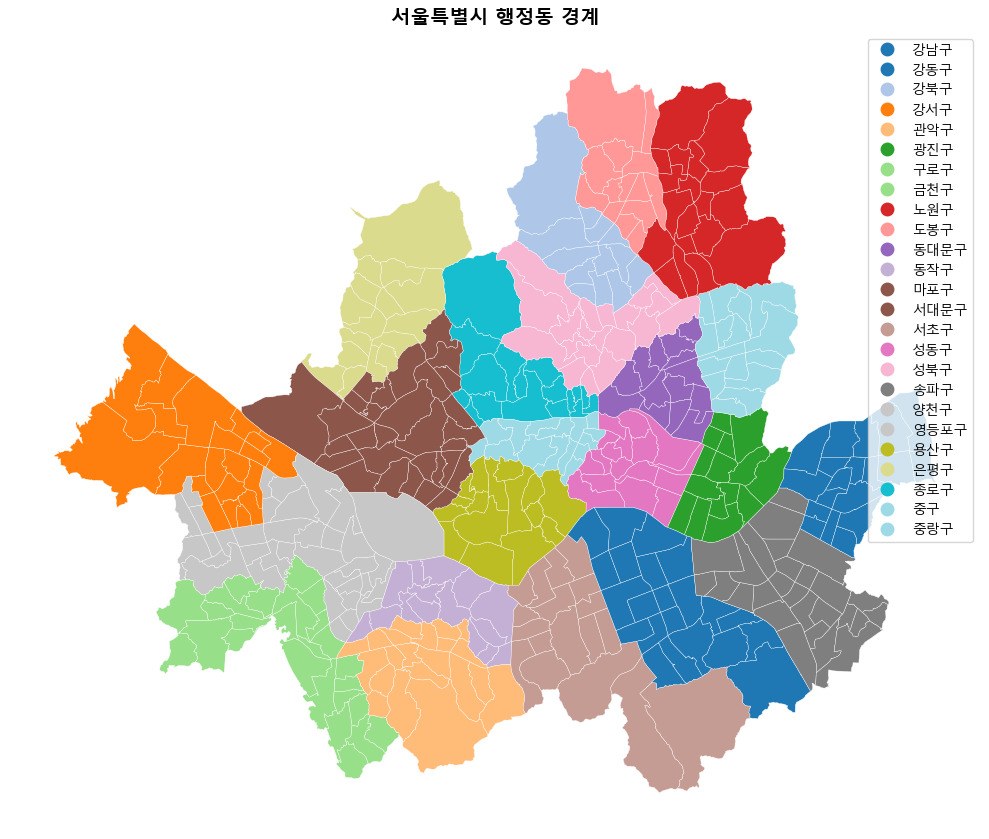

In [5]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
seoul_4326.plot(ax=ax, column="GU_NM", cmap="tab20", edgecolor="white", linewidth=0.25, legend=True)
ax.set_title("서울특별시 행정동 경계", fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. Save Outputs

In [6]:
boundary_path = OUT / "seoul_boundary.gpkg"
crosswalk_path = OUT / "admin_code_crosswalk.csv"

if boundary_path.exists():
    boundary_path.unlink()

seoul_4326.to_file(boundary_path, layer="dong", driver="GPKG")
city_boundary.to_file(boundary_path, layer="city", driver="GPKG")
seoul_projected.to_file(boundary_path, layer="dong_5179", driver="GPKG")
crosswalk.to_csv(crosswalk_path, index=False, encoding="utf-8-sig")

print("Saved outputs:")
print(f"  {boundary_path}")
print(f"  {crosswalk_path}")

Saved outputs:
  C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\processed\seoul_boundary.gpkg
  C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\processed\admin_code_crosswalk.csv


## 7. Validation

In [7]:
import pyogrio

layers = {name: geom for name, geom in pyogrio.list_layers(boundary_path)}
required_layers = {"dong", "city", "dong_5179"}
missing_layers = required_layers - set(layers)

dong_check = gpd.read_file(boundary_path, layer="dong")
city_check = gpd.read_file(boundary_path, layer="city")
projected_check = gpd.read_file(boundary_path, layer="dong_5179")
crosswalk_check = pd.read_csv(crosswalk_path, encoding="utf-8-sig")

assert len(dong_check) == 426, f"Expected 426 Seoul dongs, got {len(dong_check)}"
assert dong_check["GU_NM"].nunique() == 25, f"Expected 25 gu, got {dong_check['GU_NM'].nunique()}"
assert len(city_check) == 1, f"Expected one dissolved city boundary, got {len(city_check)}"
assert not missing_layers, f"Missing GeoPackage layers: {missing_layers}"
assert not crosswalk_check["SHP_ADM_CD"].duplicated().any(), "Duplicate SHP_ADM_CD found in crosswalk"

expected_cols = ["SHP_ADM_CD", "CSV_ADMI_CD", "GU_NM", "DONG_NM"]
assert list(crosswalk_check.columns) == expected_cols, f"Unexpected crosswalk columns: {crosswalk_check.columns.tolist()}"

print("Validation passed")
print(f"  dong rows       : {len(dong_check)}")
print(f"  gu count        : {dong_check['GU_NM'].nunique()}")
print(f"  city rows       : {len(city_check)}")
print(f"  dong_5179 rows  : {len(projected_check)}")
print(f"  layers          : {sorted(layers)}")
print(f"  crosswalk rows  : {len(crosswalk_check)}")
print(f"  missing CSV code: {crosswalk_check['CSV_ADMI_CD'].isna().sum()}")

Validation passed
  dong rows       : 426
  gu count        : 25
  city rows       : 1
  dong_5179 rows  : 426
  layers          : ['city', 'dong', 'dong_5179']
  crosswalk rows  : 426
  missing CSV code: 8
